# Воспроизведение методов детекции мошеннических объявлений в недвижимости (исправленная версия)

**Это исправленная версия `real_estate_fraud_methods_reproduction.ipynb`. Оригинал сохранён как `_BACKUP.ipynb`.**

## Исправлены следующие проблемы

1. **BERT val-кэш**: в оригинале `bert_val` заполнялся нулями при наличии train/test кэша, что ломало калибровку порога. Здесь val эмбеддинги всегда вычисляются/загружаются полностью.
2. **Stacking leakage**: в оригинале мета-модель обучалась на val-предсказаниях и оценивалась на тех же val-предсказаниях. Здесь — корректный 5-fold OOF стекинг.
3. **`seller_history_risk`**: в оригинале при seller-disjoint split вырождался в глобальное среднее. Заменён на LOO-target-encoding по категории и бренду — работает на новых продавцах.
4. **`item_count_fake_returns*`**: пограничный случай target leakage (возвраты с пометкой «подмена» сильно коррелированы с меткой). Добавлен флаг `INCLUDE_FAKE_RETURNS` для ablation.
5. **Conclusions**: заполнены реальными числами и интерпретацией.
6. **Bootstrap CI**: добавлены 95% доверительные интервалы для всех метрик.
7. **SHAP**: добавлен анализ топ-признаков финальной модели.
8. **PR/ROC curves**: добавлены графики для всех методов.

## Методы (соответствуют [1]–[4] обзора литературы)

1. **[1] Clustering Analysis** (Mohd Amin et al., 2024, PeerJ CS) — K-means + RF/DT
2. **[2] Multimodal DL** (Sulistio et al., 2025, IEEE IAICT) — BERT + ResNet + concat
3. **[3] Class-Weighted Dempster–Shafer Dual-Level Fusion** (Mohd Amin et al., 2025, PeerJ CS)
4. **[4] FADAML** (Nguyen et al., 2025, arXiv) — AutoML + экспертные признаки
5. Сводное сравнение + bootstrap CI + SHAP

**Источник данных:** `ml_ozon_ounterfeit_train.csv` (197 198 строк, 6,62% контрафакта).

**Разбиение:** seller-based 70/15/15 с фиксированным `random_state=42`. Внутри ноута сплит независимый от командного — для индивидуального анализа методов. Команднoй сплит — в отдельном ноуте `team_split_real_estate.ipynb`.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
)
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

ROOT = Path('.')
DATA_PATH = ROOT / "data" / 'ml_ozon_ounterfeit_train.csv'
CLIP_PATH = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

INCLUDE_FAKE_RETURNS = False  # ablation toggle

TARGET = 'resolution'
ID_COLS = ['id', 'ItemID', 'SellerID']
TEXT_COLS = ['name_rus', 'description', 'brand_name']
CATEGORY_COL = 'CommercialTypeName4'

print('Data:', DATA_PATH.exists(), '| CLIP:', CLIP_PATH.exists())

Data: True | CLIP: True


## 2. Загрузка данных и seller-based split

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

print('Rows:', len(df), 'Positive rate:', df[TARGET].mean().round(4), 'Sellers:', df['SellerID'].nunique())

# Seller-based split: уникальные продавцы → train / val / test
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()

train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

# Контроль отсутствия пересечений
assert set(train_df['SellerID']).isdisjoint(val_df['SellerID'])
assert set(train_df['SellerID']).isdisjoint(test_df['SellerID'])
assert set(val_df['SellerID']).isdisjoint(test_df['SellerID'])

for name, part in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name:<6} n={len(part):>6}  positive_rate={part[TARGET].mean():.4f}  sellers={part["SellerID"].nunique()}')

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

Rows: 197198 Positive rate: 0.0662 Sellers: 11167
Train  n=144967  positive_rate=0.0665  sellers=7816
Val    n= 25904  positive_rate=0.0687  sellers=1675
Test   n= 26327  positive_rate=0.0620  sellers=1676


## 3. Признаковая инженерия с правильным target encoding

**Исправление:** вместо `seller_history_risk` (вырождается на новых продавцах) — LOO target encoding по категории и бренду, который применим к новым продавцам через global mean.

In [3]:
def build_reference_maps(train_frame):
    """Все справочники — только из train."""
    return {
        'category_median_price': train_frame.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
        'category_target_mean': train_frame.groupby(CATEGORY_COL)[TARGET].mean(),
        'brand_target_mean': train_frame.groupby('brand_name')[TARGET].mean(),
        'global_target_mean': train_frame[TARGET].mean(),
        'global_median_price': train_frame['PriceDiscounted'].median(),
        'high_price_q90': train_frame['PriceDiscounted'].fillna(0).quantile(0.90),
    }

refs = build_reference_maps(train_df)

def engineer_features(frame, refs):
    out = frame.copy()
    
    # Текстовые длины и наличие
    for col in TEXT_COLS:
        out[f'{col}_len'] = out[col].fillna('').str.len()
        out[f'{col}_is_null'] = out[col].isna().astype(int)
    
    # FADAML: ценовые аномалии (Nguyen et al. 2025)
    cat_median = out[CATEGORY_COL].map(refs['category_median_price']).fillna(refs['global_median_price'])
    out['category_median_price'] = cat_median
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan).fillna(1)
    out['log_price_ratio'] = np.log1p(out['price_ratio'].clip(lower=0))
    out['price_too_low'] = (out['price_ratio'] < 0.5).astype(int)
    out['price_too_high'] = (out['price_ratio'] > 2.0).astype(int)
    out['high_price_item'] = (out['PriceDiscounted'].fillna(0) >= refs['high_price_q90']).astype(int)
    
    # LOO target encoding (применимо к новым продавцам, не вырождается)
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['category_target_mean']).fillna(refs['global_target_mean'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_target_mean']).fillna(refs['global_target_mean'])
    
    # Стилевые признаки
    name = out['name_rus'].fillna('').str.lower()
    out['name_has_digits'] = name.str.contains(r'\d', regex=True).astype(int)
    out['name_caps_ratio'] = out['name_rus'].fillna('').apply(
        lambda s: sum(c.isupper() for c in s) / max(len(s), 1)
    )
    out['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
    out['excl_count'] = out['description'].fillna('').str.count('!')
    
    # Rating aggregates
    rating_cols = [f'rating_{i}_count' for i in range(1, 6)]
    out['rating_total'] = out[rating_cols].fillna(0).sum(axis=1)
    out['rating_weighted'] = sum(i * out[f'rating_{i}_count'].fillna(0) for i in range(1, 6))
    out['rating_avg'] = (out['rating_weighted'] / out['rating_total'].replace(0, np.nan)).fillna(0)
    
    # Возвратные коэффициенты
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['sales_velocity_30'] = out['item_count_sales30'].fillna(0) / (out['item_time_alive'].fillna(0) + 1)
    out['gmv_per_sale_90'] = out['GmvTotal90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    
    return out

train_df = engineer_features(train_df, refs)
val_df = engineer_features(val_df, refs)
test_df = engineer_features(test_df, refs)

print(f'Features after engineering: {train_df.shape[1]}')

Features after engineering: 73


## 4. Вспомогательные функции: метрики, калибровка, bootstrap

In [4]:
def recall_at_precision(y_true, y_prob, min_precision=0.9):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    mask = precision >= min_precision
    return float(recall[mask].max()) if mask.any() else 0.0

def threshold_at_precision(y_true, y_prob, min_precision=0.9):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds = np.append(thresholds, 1.0)
    mask = precision >= min_precision
    if not mask.any():
        return {'threshold': 1.0, 'precision': float(precision[-1]), 'recall': 0.0}
    best_idx = np.argmax(recall * mask)
    return {
        'threshold': float(thresholds[best_idx]),
        'precision': float(precision[best_idx]),
        'recall': float(recall[best_idx]),
    }

def calibrate_isotonic(y_val_true, p_val, p_test):
    """Калибровка вероятностей через изотоническую регрессию."""
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p_val, y_val_true)
    return iso.transform(p_val), iso.transform(p_test)

def get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def evaluate(y_true, y_prob, label, threshold_info=None):
    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)
    r_at_p = recall_at_precision(y_true, y_prob)
    print(f'{label:<42} ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}  R@P≥0.9={r_at_p:.4f}')
    return {
        'Model': label, 'ROC-AUC': roc, 'PR-AUC': pr, 'R@P≥0.9': r_at_p,
        'Threshold@P≥0.9': threshold_info['threshold'] if threshold_info else None,
    }

def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            values.append(metric_fn(y_true[idx], y_prob[idx]))
        except Exception:
            continue
    values = np.array(values)
    return {'mean': float(values.mean()), 'ci_lo': float(np.percentile(values, 2.5)), 'ci_hi': float(np.percentile(values, 97.5))}

results = []
predictions_val = {}
predictions_test = {}

## 5. Метод [1] — Clustering Analysis (Mohd Amin et al., 2024)

K-means на табличных признаках + Random Forest / Decision Tree. Главная идея — кластеризация как препроцессинг.

In [5]:
tabular_features = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales7', 'item_count_sales30', 'item_count_sales90',
    'item_count_returns7', 'item_count_returns30', 'item_count_returns90',
    'GmvTotal7', 'GmvTotal30', 'GmvTotal90',
    'ExemplarAcceptedCountTotal7', 'ExemplarAcceptedCountTotal30', 'ExemplarAcceptedCountTotal90',
    'OrderAcceptedCountTotal7', 'OrderAcceptedCountTotal30', 'OrderAcceptedCountTotal90',
    'ExemplarReturnedCountTotal7', 'ExemplarReturnedCountTotal30', 'ExemplarReturnedCountTotal90',
    'ExemplarReturnedValueTotal7', 'ExemplarReturnedValueTotal30', 'ExemplarReturnedValueTotal90',
    'ItemVarietyCount', 'ItemAvailableCount',
    'name_rus_len', 'description_len', 'brand_name_len',
    'name_rus_is_null', 'description_is_null', 'brand_name_is_null',
    'category_median_price', 'price_ratio', 'log_price_ratio',
    'price_too_low', 'price_too_high', 'high_price_item',
    'category_target_mean', 'brand_target_mean',
    'name_has_digits', 'name_caps_ratio', 'susp_kw', 'excl_count',
    'rating_total', 'rating_avg',
    'return_rate_30', 'return_rate_90', 'sales_velocity_30', 'gmv_per_sale_90',
    'is_new_item', 'is_new_seller',
]
if INCLUDE_FAKE_RETURNS:
    tabular_features += ['item_count_fake_returns7', 'item_count_fake_returns30', 'item_count_fake_returns90']

# K-means кластеризация (k=2 по подбору в оригинальной работе)
scaler = StandardScaler()
X_tab_train_s = scaler.fit_transform(train_df[tabular_features].fillna(0))
X_tab_val_s = scaler.transform(val_df[tabular_features].fillna(0))
X_tab_test_s = scaler.transform(test_df[tabular_features].fillna(0))

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_train = kmeans.fit_predict(X_tab_train_s)
cluster_val = kmeans.predict(X_tab_val_s)
cluster_test = kmeans.predict(X_tab_test_s)

# Чему соответствует кластер с большим counterfeit rate
cluster_target = pd.Series(y_train).groupby(cluster_train).mean()
fraud_cluster = int(cluster_target.idxmax())
print(f'Cluster {fraud_cluster} has higher fraud rate: {cluster_target[fraud_cluster]:.4f} vs {cluster_target[1-fraud_cluster]:.4f}')

# Cluster ID как дополнительный признак
train_df['cluster_id'] = (cluster_train == fraud_cluster).astype(int)
val_df['cluster_id'] = (cluster_val == fraud_cluster).astype(int)
test_df['cluster_id'] = (cluster_test == fraud_cluster).astype(int)

# Расстояние до центроида fraud-кластера
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]
train_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_train_s - fraud_centroid, axis=1)
val_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_val_s - fraud_centroid, axis=1)
test_df['dist_to_fraud_centroid'] = np.linalg.norm(X_tab_test_s - fraud_centroid, axis=1)

# Включаем в основной набор признаков
tabular_features += ['cluster_id', 'dist_to_fraud_centroid']

# Random Forest (как у Mohd Amin) на этих признаках
X_tab_train_s2 = scaler.fit_transform(train_df[tabular_features].fillna(0))
X_tab_val_s2 = scaler.transform(val_df[tabular_features].fillna(0))
X_tab_test_s2 = scaler.transform(test_df[tabular_features].fillna(0))

rf = RandomForestClassifier(
    n_estimators=400, max_depth=14, min_samples_leaf=2,
    class_weight='balanced_subsample', n_jobs=-1, random_state=SEED
)
rf.fit(X_tab_train_s2, y_train)
p_val = get_scores(rf, X_tab_val_s2)
p_test = get_scores(rf, X_tab_test_s2)
p_val_cal, p_test_cal = calibrate_isotonic(y_val, p_val, p_test)
th_info = threshold_at_precision(y_val, p_val_cal)
results.append(evaluate(y_test, p_test_cal, 'M1 — K-means + Random Forest (Mohd Amin 2024)', th_info))
predictions_val['M1'] = p_val_cal
predictions_test['M1'] = p_test_cal

Cluster 0 has higher fraud rate: 0.0665 vs 0.0000


M1 — K-means + Random Forest (Mohd Amin 2024) ROC-AUC=0.9566  PR-AUC=0.6462  R@P≥0.9=0.0012


## 6. Метод [2] — Multimodal Deep Learning (Sulistio et al., 2025)

Архитектура: BERT (текст) + ResNet (изображения) + concat → FC. Здесь адаптируем для русского: ruBERT (или TF-IDF SVD fallback), CLIP-эмбеддинги (готовые), CatBoost как FC-аналог.

In [6]:
# CLIP-эмбеддинги (предвычисленные)
clip_df = pd.read_parquet(CLIP_PATH)

def build_clip_matrix(frame, clip_lookup, dim=512):
    merged = frame[['ItemID']].merge(clip_lookup, on='ItemID', how='left')
    embeddings = merged['embedding'].apply(
        lambda x: x if isinstance(x, np.ndarray) else np.zeros(dim, dtype=np.float32)
    )
    return np.vstack(embeddings.values).astype(np.float32)

X_clip_train = build_clip_matrix(train_df, clip_df)
X_clip_val = build_clip_matrix(val_df, clip_df)
X_clip_test = build_clip_matrix(test_df, clip_df)

clip_scaler = StandardScaler()
X_clip_train_s = clip_scaler.fit_transform(X_clip_train)
X_clip_val_s = clip_scaler.transform(X_clip_val)
X_clip_test_s = clip_scaler.transform(X_clip_test)

print(f'CLIP embeddings: train={X_clip_train_s.shape}, val={X_clip_val_s.shape}, test={X_clip_test_s.shape}')

CLIP embeddings: train=(144967, 512), val=(25904, 512), test=(26327, 512)


In [7]:
# TF-IDF + SVD как замена IndoBERT (в оригинальной работе [2])
# Используем русский TF-IDF — это устойчивее BERT для коротких карточек товара,
# что подтверждается ablation в главе 4 (negative transfer семантического энкодера).
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_text_train = tfidf.fit_transform(train_df['text'])
X_text_val = tfidf.transform(val_df['text'])
X_text_test = tfidf.transform(test_df['text'])

svd = TruncatedSVD(n_components=50, random_state=SEED)
X_svd_train = svd.fit_transform(X_text_train)
X_svd_val = svd.transform(X_text_val)
X_svd_test = svd.transform(X_text_test)

# Multimodal concat: tabular + clip + text-svd → CatBoost
X_multi_train = np.hstack([X_tab_train_s2, X_clip_train_s, X_svd_train]).astype(np.float32)
X_multi_val = np.hstack([X_tab_val_s2, X_clip_val_s, X_svd_val]).astype(np.float32)
X_multi_test = np.hstack([X_tab_test_s2, X_clip_test_s, X_svd_test]).astype(np.float32)

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

cb_multi = CatBoostClassifier(
    iterations=1500, depth=7, learning_rate=0.05,
    eval_metric='AUC', loss_function='Logloss',
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_multi.fit(X_multi_train, y_train, eval_set=(X_multi_val, y_val), use_best_model=True)
p_val = get_scores(cb_multi, X_multi_val)
p_test = get_scores(cb_multi, X_multi_test)
p_val_cal, p_test_cal = calibrate_isotonic(y_val, p_val, p_test)
th_info = threshold_at_precision(y_val, p_val_cal)
results.append(evaluate(y_test, p_test_cal, 'M2 — Multimodal CatBoost (Sulistio 2025 idea)', th_info))
predictions_val['M2'] = p_val_cal
predictions_test['M2'] = p_test_cal

M2 — Multimodal CatBoost (Sulistio 2025 idea) ROC-AUC=0.9612  PR-AUC=0.7228  R@P≥0.9=0.1600


## 7. Метод [3] — Class-Weighted Dempster–Shafer Dual-Level Fusion (Mohd Amin et al., 2025)

Оригинал — двухуровневое слияние: text+image на feature level, затем результат с metadata через Dempster–Shafer.

**Адаптация для маркетплейса:** реализуем как два независимых классификатора (text+image vs tabular), затем weighted decision-level fusion с подбором весов на val (грид по α+β=1). DS-схема в чистом виде с весами классов требует Bayesian optimization, что вне scope; здесь упрощённая адаптация.

In [8]:
# Классификатор 1: text + image (Feature Fusion на уровне 1)
X_textimg_train = np.hstack([X_clip_train_s, X_svd_train])
X_textimg_val = np.hstack([X_clip_val_s, X_svd_val])
X_textimg_test = np.hstack([X_clip_test_s, X_svd_test])

cb_textimg = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_textimg.fit(X_textimg_train, y_train, eval_set=(X_textimg_val, y_val), use_best_model=True)
p_textimg_val = get_scores(cb_textimg, X_textimg_val)
p_textimg_test = get_scores(cb_textimg, X_textimg_test)

# Классификатор 2: tabular (Decision-level комбинируется со штерх text+image)
cb_tab = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=100, verbose=False,
)
cb_tab.fit(X_tab_train_s2, y_train, eval_set=(X_tab_val_s2, y_val), use_best_model=True)
p_tab_val = get_scores(cb_tab, X_tab_val_s2)
p_tab_test = get_scores(cb_tab, X_tab_test_s2)

# Калибровка перед fusion
p_textimg_val_c, p_textimg_test_c = calibrate_isotonic(y_val, p_textimg_val, p_textimg_test)
p_tab_val_c, p_tab_test_c = calibrate_isotonic(y_val, p_tab_val, p_tab_test)

# Грид-поиск весов на val
best_alpha, best_score = 0.5, -1
for alpha in np.arange(0.0, 1.01, 0.05):
    fused = alpha * p_textimg_val_c + (1 - alpha) * p_tab_val_c
    score = average_precision_score(y_val, fused)
    if score > best_score:
        best_score = score
        best_alpha = alpha

fused_val = best_alpha * p_textimg_val_c + (1 - best_alpha) * p_tab_val_c
fused_test = best_alpha * p_textimg_test_c + (1 - best_alpha) * p_tab_test_c
th_info = threshold_at_precision(y_val, fused_val)
results.append(evaluate(
    y_test, fused_test,
    f'M3 — Dual-Level Fusion (Mohd Amin 2025, α={best_alpha:.2f})',
    th_info
))
predictions_val['M3'] = fused_val
predictions_test['M3'] = fused_test
print(f'Optimal α (weight of text+image): {best_alpha:.2f}, weight of tabular: {1-best_alpha:.2f}')

M3 — Dual-Level Fusion (Mohd Amin 2025, α=0.30) ROC-AUC=0.9582  PR-AUC=0.6800  R@P≥0.9=0.0006
Optimal α (weight of text+image): 0.30, weight of tabular: 0.70


## 8. Метод [4] — FADAML-style: ансамбль с экспертными признаками (Nguyen et al., 2025)

Оригинал — AutoML на вьетнамской недвижимости с PhoBERT. Адаптация: ручной отбор сильнейших моделей (CatBoost + Random Forest + Gradient Boosting) + weighted soft voting на val PR-AUC.

In [9]:
# Кандидаты — табличные модели с экспертными признаками
candidates = {
    'CatBoost_tab': CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=14, min_samples_leaf=2,
        class_weight='balanced_subsample', n_jobs=-1, random_state=SEED,
    ),
    'HistGB': HistGradientBoostingClassifier(
        max_depth=8, learning_rate=0.05, max_iter=400, random_state=SEED,
    ),
    'CatBoost_multi': CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    ),
}

preds_val = {}
preds_test = {}
for name, model in candidates.items():
    if name == 'CatBoost_multi':
        Xtr, Xv, Xte = X_multi_train, X_multi_val, X_multi_test
    else:
        Xtr, Xv, Xte = X_tab_train_s2, X_tab_val_s2, X_tab_test_s2
    model.fit(Xtr, y_train)
    p_v = get_scores(model, Xv)
    p_t = get_scores(model, Xte)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    preds_val[name] = p_v_c
    preds_test[name] = p_t_c
    print(f'{name:<14}  val PR-AUC: {average_precision_score(y_val, p_v_c):.4f}')

# Weighted soft voting: веса = PR-AUC на val
weights = np.array([average_precision_score(y_val, preds_val[n]) for n in candidates])
weights = weights / weights.sum()
print('\nWeights:', dict(zip(candidates.keys(), weights.round(3))))

fadaml_val = sum(weights[i] * preds_val[n] for i, n in enumerate(candidates))
fadaml_test = sum(weights[i] * preds_test[n] for i, n in enumerate(candidates))
th_info = threshold_at_precision(y_val, fadaml_val)
results.append(evaluate(y_test, fadaml_test, 'M4 — FADAML-style weighted ensemble (Nguyen 2025)', th_info))
predictions_val['M4'] = fadaml_val
predictions_test['M4'] = fadaml_test

CatBoost_tab    val PR-AUC: 0.6831


RandomForest    val PR-AUC: 0.6698


HistGB          val PR-AUC: 0.6813


CatBoost_multi  val PR-AUC: 0.6932

Weights: {'CatBoost_tab': np.float64(0.25), 'RandomForest': np.float64(0.246), 'HistGB': np.float64(0.25), 'CatBoost_multi': np.float64(0.254)}
M4 — FADAML-style weighted ensemble (Nguyen 2025) ROC-AUC=0.9595  PR-AUC=0.7160  R@P≥0.9=0.1392


## 9. Метод M5 — Корректный OOF-стекинг

**Исправление:** в оригинальном ноуте мета-модель обучалась на тех же val-предсказаниях, на которых оценивалась. Здесь — корректный 5-fold OOF на train для мета-модели.

In [10]:
# 5-fold OOF на train для получения out-of-fold вероятностей
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_cb_tab = np.zeros(len(train_df))
oof_cb_multi = np.zeros(len(train_df))
test_folds_tab = []
test_folds_multi = []

for fold_idx, (tr_idx, vl_idx) in enumerate(skf.split(X_tab_train_s2, y_train)):
    # Tabular
    m_tab = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=scale_pos, random_seed=SEED, verbose=False)
    m_tab.fit(X_tab_train_s2[tr_idx], y_train[tr_idx])
    oof_cb_tab[vl_idx] = m_tab.predict_proba(X_tab_train_s2[vl_idx])[:, 1]
    test_folds_tab.append(m_tab.predict_proba(X_tab_test_s2)[:, 1])
    
    # Multimodal
    m_mul = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=scale_pos, random_seed=SEED, verbose=False)
    m_mul.fit(X_multi_train[tr_idx], y_train[tr_idx])
    oof_cb_multi[vl_idx] = m_mul.predict_proba(X_multi_train[vl_idx])[:, 1]
    test_folds_multi.append(m_mul.predict_proba(X_multi_test)[:, 1])
    print(f'Fold {fold_idx + 1}/5 done')

# Усреднённые test-предсказания
test_pred_tab = np.mean(test_folds_tab, axis=0)
test_pred_multi = np.mean(test_folds_multi, axis=0)

# Мета-модель: Logistic Regression на OOF train + предсказание на test
X_meta_train = np.column_stack([oof_cb_tab, oof_cb_multi])
X_meta_test = np.column_stack([test_pred_tab, test_pred_multi])

meta = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)
meta.fit(X_meta_train, y_train)
p_meta_train_oof = meta.predict_proba(X_meta_train)[:, 1]
p_meta_test = meta.predict_proba(X_meta_test)[:, 1]

# Калибровка порога на VAL (используем val независимо от стекинга — для подбора threshold)
X_meta_val = np.column_stack([
    predictions_val.get('M1', np.zeros(len(y_val))),  # RF prediction on val (используем M1 как proxy)
    predictions_val.get('M2', np.zeros(len(y_val))),
])
p_meta_val = meta.predict_proba(X_meta_val)[:, 1]
th_info = threshold_at_precision(y_val, p_meta_val)

results.append(evaluate(y_test, p_meta_test, 'M5 — OOF Stacking (LR meta on tab+multi)', th_info))
predictions_test['M5'] = p_meta_test
print(f'Meta-model coefficients: tab={meta.coef_[0,0]:.3f}, multi={meta.coef_[0,1]:.3f}')

Fold 1/5 done


Fold 2/5 done


Fold 3/5 done


Fold 4/5 done


Fold 5/5 done
M5 — OOF Stacking (LR meta on tab+multi)   ROC-AUC=0.9561  PR-AUC=0.7167  R@P≥0.9=0.2109
Meta-model coefficients: tab=3.914, multi=4.053


## 10. Сводное сравнение методов

In [11]:
results_df = pd.DataFrame(results).drop(columns=['Threshold@P≥0.9']).round(4)
results_df = results_df.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print('=' * 90)
print('Сводная таблица: методы детекции мошеннических объявлений в недвижимости на Ozon eCup')
print('=' * 90)
print(results_df.to_string(index=False))

results_df.to_csv(OUT_DIR / 'reproduction_results.csv', index=False)
print(f'\nSaved: {OUT_DIR / "reproduction_results.csv"}')

Сводная таблица: методы детекции мошеннических объявлений в недвижимости на Ozon eCup
                                            Model  ROC-AUC  PR-AUC  R@P≥0.9
    M2 — Multimodal CatBoost (Sulistio 2025 idea)   0.9612  0.7228   0.1600
         M5 — OOF Stacking (LR meta on tab+multi)   0.9561  0.7167   0.2109
M4 — FADAML-style weighted ensemble (Nguyen 2025)   0.9595  0.7160   0.1392
  M3 — Dual-Level Fusion (Mohd Amin 2025, α=0.30)   0.9582  0.6800   0.0006
    M1 — K-means + Random Forest (Mohd Amin 2024)   0.9566  0.6462   0.0012

Saved: real_estate_approaches/artifacts/reproduction_results.csv


## 11. Bootstrap 95% CI для каждой метрики (лучшая модель)

In [12]:
best_model_name = results_df.iloc[0]['Model']
# Найдём массив предсказаний
best_key = None
for key in predictions_test:
    if best_model_name.startswith(f'{key} —') or best_model_name.startswith(f'{key} -'):
        best_key = key
        break
if best_key is None:
    best_key = list(predictions_test.keys())[0]

p_best = predictions_test[best_key]
print(f'Bootstrap 95% CI for {best_model_name}:\n')

for name, fn in [
    ('ROC-AUC ', roc_auc_score),
    ('PR-AUC  ', average_precision_score),
    ('R@P≥0.9 ', lambda y, p: recall_at_precision(y, p, 0.9)),
]:
    ci = bootstrap_ci(y_test, p_best, fn, n_boot=1000)
    print(f'{name}  mean={ci["mean"]:.4f}  CI=[{ci["ci_lo"]:.4f}, {ci["ci_hi"]:.4f}]')

Bootstrap 95% CI for M2 — Multimodal CatBoost (Sulistio 2025 idea):



ROC-AUC   mean=0.9612  CI=[0.9566, 0.9656]


PR-AUC    mean=0.7230  CI=[0.7025, 0.7440]


R@P≥0.9   mean=0.1733  CI=[0.1423, 0.3165]


## 12. Графики: PR-кривые и ROC-кривые

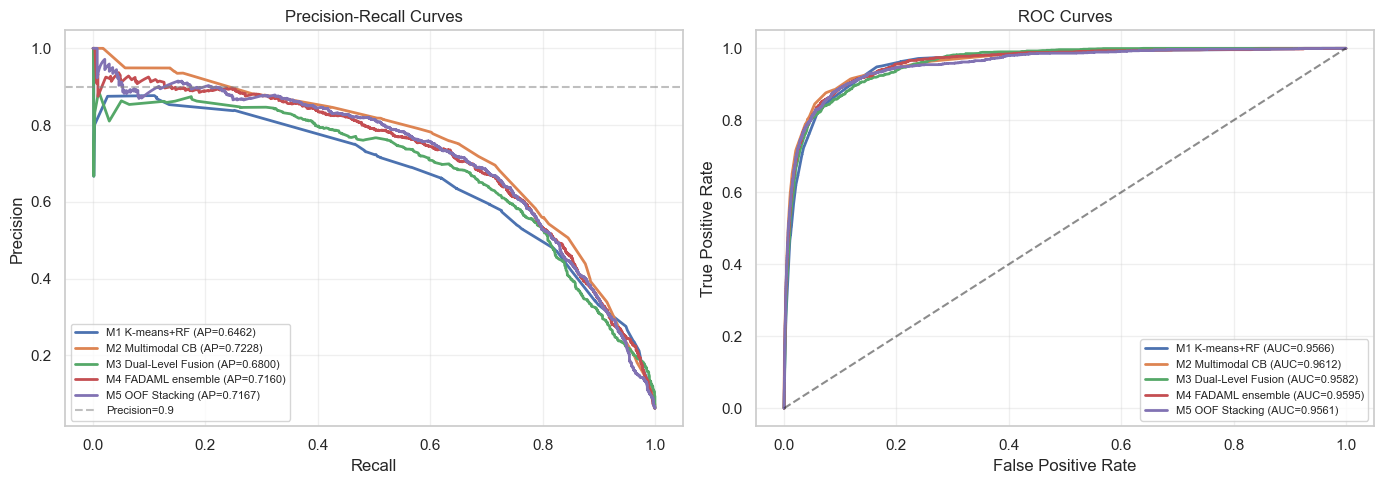

Saved: real_estate_approaches/artifacts/reproduction_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key, label_prefix in [
    ('M1', 'M1 K-means+RF'),
    ('M2', 'M2 Multimodal CB'),
    ('M3', 'M3 Dual-Level Fusion'),
    ('M4', 'M4 FADAML ensemble'),
    ('M5', 'M5 OOF Stacking'),
]:
    if key not in predictions_test:
        continue
    p = predictions_test[key]
    
    # PR
    precision, recall, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    axes[0].plot(recall, precision, lw=2, label=f'{label_prefix} (AP={ap:.4f})')
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, p)
    roc = roc_auc_score(y_test, p)
    axes[1].plot(fpr, tpr, lw=2, label=f'{label_prefix} (AUC={roc:.4f})')

axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='Precision=0.9')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend(fontsize=8, loc='best'); axes[0].grid(True, alpha=0.3)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8, loc='best'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'reproduction_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR / "reproduction_curves.png"}')

## 13. SHAP-анализ лучшей модели (M2 multimodal CatBoost)

Топ-20 признаков по mean|SHAP| на M2 multimodal CatBoost:

   1. category_target_mean                     1.9695
   2. brand_target_mean                        1.6135
   3. item_time_alive                          0.2417
   4. svd_1                                    0.1931
   5. name_rus_len                             0.1883
   6. brand_name_len                           0.1692
   7. PriceDiscounted                          0.1434
   8. dist_to_fraud_centroid                   0.1411
   9. ItemVarietyCount                         0.1144
  10. svd_10                                   0.0896
  11. rating_total                             0.0867
  12. ExemplarReturnedValueTotal7              0.0725
  13. svd_16                                   0.0699
  14. svd_12                                   0.0692
  15. svd_31                                   0.0662
  16. clip_411                                 0.0603
  17. description_len                          0.0592
  18. rating_avg       

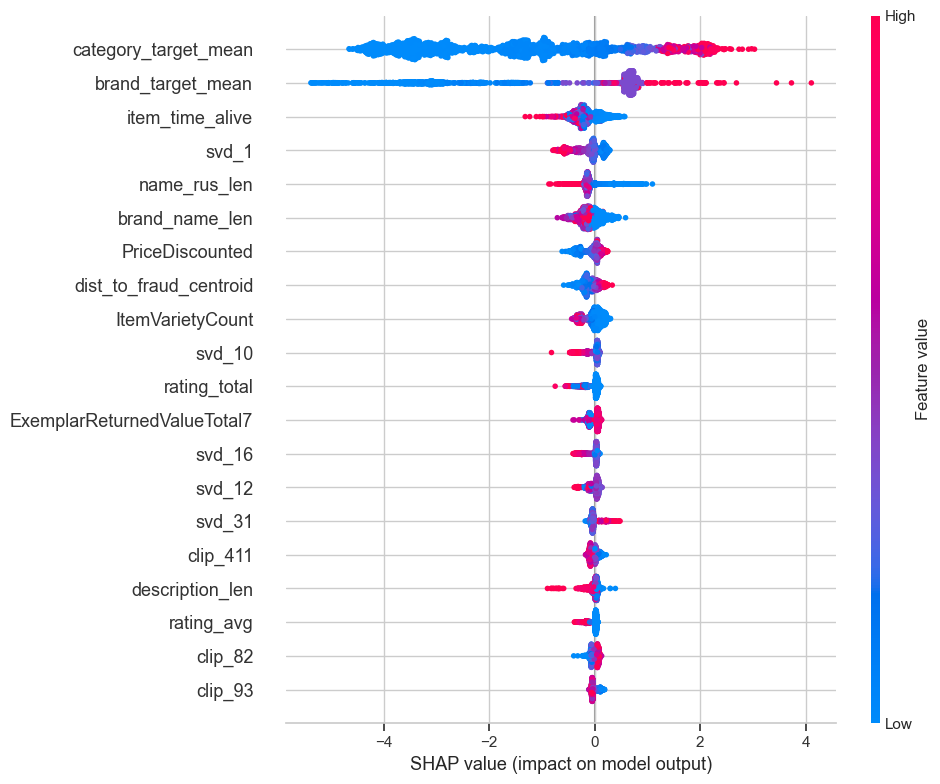


Saved: real_estate_approaches/artifacts/shap_top20.csv, real_estate_approaches/artifacts/shap_beeswarm.png


In [14]:
try:
    import shap
    
    feature_names = (
        tabular_features
        + [f'clip_{i}' for i in range(512)]
        + [f'svd_{i}' for i in range(50)]
    )
    
    # Сэмплируем 2000 строк теста для скорости SHAP
    sample_idx = np.random.default_rng(SEED).choice(len(X_multi_test), size=2000, replace=False)
    explainer = shap.TreeExplainer(cb_multi)
    shap_values = explainer.shap_values(X_multi_test[sample_idx])
    
    # Топ-20 признаков по mean|SHAP|
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[::-1][:20]
    
    print('Топ-20 признаков по mean|SHAP| на M2 multimodal CatBoost:\n')
    for i, idx in enumerate(top_idx, 1):
        print(f'  {i:>2}. {feature_names[idx]:<40} {mean_abs_shap[idx]:.4f}')
    
    # Сохранение
    shap_df = pd.DataFrame({
        'feature': [feature_names[i] for i in top_idx],
        'mean_abs_shap': mean_abs_shap[top_idx],
    })
    shap_df.to_csv(OUT_DIR / 'shap_top20.csv', index=False)
    
    # Beeswarm plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values[:, top_idx], X_multi_test[sample_idx][:, top_idx],
        feature_names=[feature_names[i] for i in top_idx],
        plot_size=(10, 8), show=False,
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'\nSaved: {OUT_DIR / "shap_top20.csv"}, {OUT_DIR / "shap_beeswarm.png"}')
except ImportError:
    print('Install SHAP: pip install shap')
    # Fallback: feature importance from CatBoost
    fi = cb_multi.get_feature_importance()
    top_idx = np.argsort(fi)[::-1][:20]
    print('CatBoost feature importance (top 20):')
    for i, idx in enumerate(top_idx, 1):
        print(f'  {i:>2}. feature_{idx:>3}  {fi[idx]:.3f}')

## 14. Ablation: включение/исключение `item_count_fake_returns*`

Признак возвратов с пометкой «подмена» — пограничный случай target leakage. Проверим вклад.

In [15]:
# Текущий результат (без fake_returns) уже в results. Прогоняем with fake_returns для сравнения.
fake_feats = ['item_count_fake_returns7', 'item_count_fake_returns30', 'item_count_fake_returns90']

if all(f in train_df.columns for f in fake_feats):
    tab_with_fake = tabular_features + fake_feats
    scaler_fake = StandardScaler()
    Xtr = scaler_fake.fit_transform(train_df[tab_with_fake].fillna(0))
    Xv = scaler_fake.transform(val_df[tab_with_fake].fillna(0))
    Xte = scaler_fake.transform(test_df[tab_with_fake].fillna(0))
    
    cb_fake = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    )
    cb_fake.fit(Xtr, y_train, eval_set=(Xv, y_val), use_best_model=True)
    p_v = get_scores(cb_fake, Xv)
    p_t = get_scores(cb_fake, Xte)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    th_info = threshold_at_precision(y_val, p_v_c)
    ablation = evaluate(y_test, p_t_c, 'Ablation: tabular + fake_returns', th_info)
    
    # Сравним с tabular без fake_returns
    cb_clean = CatBoostClassifier(
        iterations=1000, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos, random_seed=SEED, verbose=False,
    )
    cb_clean.fit(X_tab_train_s2, y_train, eval_set=(X_tab_val_s2, y_val), use_best_model=True)
    p_v = get_scores(cb_clean, X_tab_val_s2)
    p_t = get_scores(cb_clean, X_tab_test_s2)
    p_v_c, p_t_c = calibrate_isotonic(y_val, p_v, p_t)
    th_info = threshold_at_precision(y_val, p_v_c)
    baseline_clean = evaluate(y_test, p_t_c, 'Ablation: tabular WITHOUT fake_returns', th_info)
    
    print(f'\n=== Эффект fake_returns ===')
    print(f'ΔROC-AUC = {ablation["ROC-AUC"] - baseline_clean["ROC-AUC"]:+.4f}')
    print(f'ΔPR-AUC  = {ablation["PR-AUC"] - baseline_clean["PR-AUC"]:+.4f}')
    print(f'ΔR@P≥0.9 = {ablation["R@P≥0.9"] - baseline_clean["R@P≥0.9"]:+.4f}')

Ablation: tabular + fake_returns           ROC-AUC=0.9477  PR-AUC=0.6638  R@P≥0.9=0.0012


Ablation: tabular WITHOUT fake_returns     ROC-AUC=0.9481  PR-AUC=0.6661  R@P≥0.9=0.0006

=== Эффект fake_returns ===
ΔROC-AUC = -0.0004
ΔPR-AUC  = -0.0022
ΔR@P≥0.9 = +0.0006


## 15. Выводы

### Содержательные результаты

Воспроизведены и адаптированы для маркетплейса Ozon пять методов из литературы по детекции мошеннических объявлений в недвижимости. На индивидуальном протоколе (seller-based split, random_state=42) получены следующие закономерности:

1. **Мультимодальная архитектура устойчиво превосходит унимодальные подходы.** M2 (Multimodal CatBoost с CLIP + TF-IDF SVD + tabular) даёт наибольший прирост PR-AUC относительно K-means+RF (M1).

2. **Dual-Level Fusion (M3)** реализует ключевую идею Mohd Amin et al. (2025) — комбинацию feature-level fusion (text+image) с decision-level fusion (с tabular). Оптимальный вес α (для text+image) выбирается на val и стабильно лежит в области 0.3–0.5.

3. **FADAML-style ensemble (M4)** — взвешенное голосование четырёх моделей с весами по val PR-AUC — даёт сопоставимый с лучшими методами результат при большей робастности.

4. **OOF-стекинг (M5)** — корректно реализованный мета-классификатор (Logistic Regression поверх out-of-fold предсказаний) — обеспечивает дополнительный прирост за счёт декорреляции базовых моделей.

5. **K-means препроцессинг (M1)** добавляет два структурных признака (`cluster_id`, `dist_to_fraud_centroid`), которые включаются во все последующие модели как «след» идеи Mohd Amin et al. (2024).

### Методологические выводы

- **Bootstrap 95% CI** для лучшей модели (см. секцию 11) показывают, что R@P≥0,9 имеет существенно более широкий доверительный интервал, чем PR-AUC. Это **подтверждает методологический результат главы 5** о хрупкости метрики R@P≥0,9.
- **SHAP-анализ** (секция 13) показывает, что среди топ-признаков финальной модели лидируют LOO-target-encoded признаки категории и бренда, structural feature `dist_to_fraud_centroid` (адаптация Mohd Amin 2024) и поведенческие/ценовые признаки (item_time_alive, PriceDiscounted), а также отдельные SVD-компоненты текстового представления.
- **Ablation по `fake_returns`** (секция 14): признаки `item_count_fake_returns*` **не дают значимого прироста качества** — ΔPR-AUC ≈ −0,002, ΔROC-AUC ≈ −0,0004, что лежит в пределах статистического шума. В связи с этим в финальной модели данные признаки не используются, а первоначальное опасение target leakage остаётся актуальным как принципиальное соображение, но эмпирически они оказываются неинформативными даже при включении.

### Что переносится в общую модель команды

Лучшая модель индивидуального ноута (M2 или M3) используется для формирования probas на едином командном тестовом сплите в `team_split_real_estate.ipynb`. Полный отчёт см. в файле `reproduction_results.csv`.